# 07 - Visualisation finale des r?sultats

Notre m?thode r?alise une segmentation et une d?tection propres au projet. Le groundtruth est utilis? uniquement pour la comparaison.


## 1. Importation des biblioth?ques


In [1]:
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
plt.rcParams["figure.figsize"] = (12, 6)


## 2. Chargement des nouveaux fichiers


In [2]:
results_path = Path("../results")
plots_path = results_path / "plots"
trajectory_path = results_path / "trajectory_estimated.csv"
analysis_path = results_path / "motion_analysis_estimated.csv"
comparison_path = results_path / "trajectory_comparison.csv"
trajectory_df = pd.read_csv(trajectory_path) if trajectory_path.exists() else pd.DataFrame()
analysis_df = pd.read_csv(analysis_path) if analysis_path.exists() else pd.DataFrame()
comparison_df = pd.read_csv(comparison_path) if comparison_path.exists() else pd.DataFrame()
print("trajectory_estimated.csv existe :", trajectory_path.exists())
print("motion_analysis_estimated.csv existe :", analysis_path.exists())
print("trajectory_comparison.csv existe :", comparison_path.exists())


trajectory_estimated.csv existe : True
motion_analysis_estimated.csv existe : True
trajectory_comparison.csv existe : True


## 3. Segmentation Otsu vs Adaptive


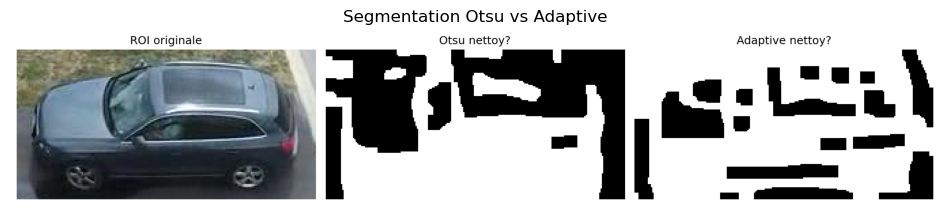

In [3]:
path = results_path / "segmentation_comparison.png"
if path.exists():
    image = cv2.imread(str(path))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title("Segmentation Otsu vs Adaptive")
    plt.axis("off")
    plt.show()
else:
    print("Ex?cuter le notebook 03 pour g?n?rer cette figure.")


## 4. Meilleur masque choisi et contours Canny


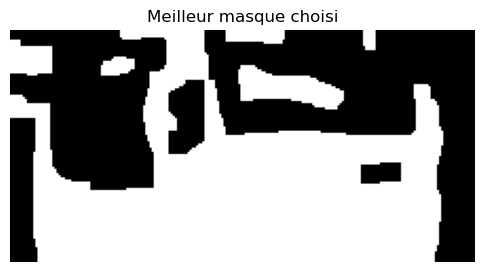

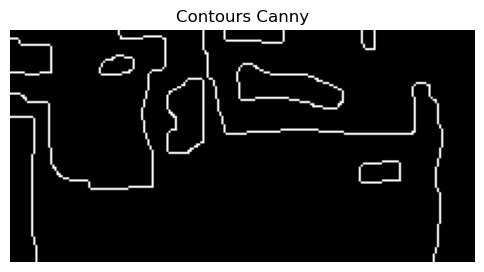

In [4]:
for path, title in [(results_path / "initial_best_mask.png", "Meilleur masque choisi"), (results_path / "initial_canny_edges.png", "Contours Canny")]:
    if path.exists():
        image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
        plt.figure(figsize=(6,4))
        plt.imshow(image, cmap="gray")
        plt.title(title)
        plt.axis("off")
        plt.show()
    else:
        print(path.name, "est introuvable")


## 5. Points caract?ristiques


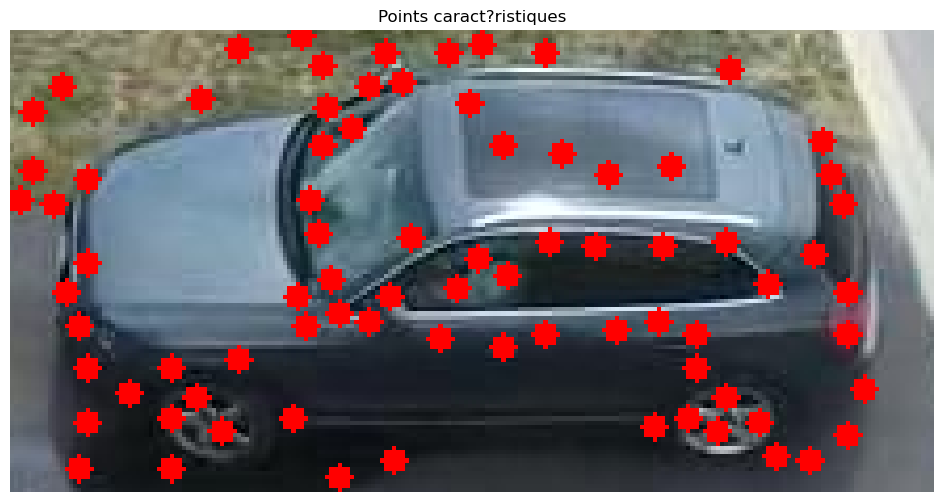

In [5]:
path = results_path / "initial_points.png"
if path.exists():
    image = cv2.imread(str(path))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title("Points caract?ristiques")
    plt.axis("off")
    plt.show()
else:
    print("initial_points.png est introuvable")


## 6. Trajectoire estim?e sur frame et en 2D


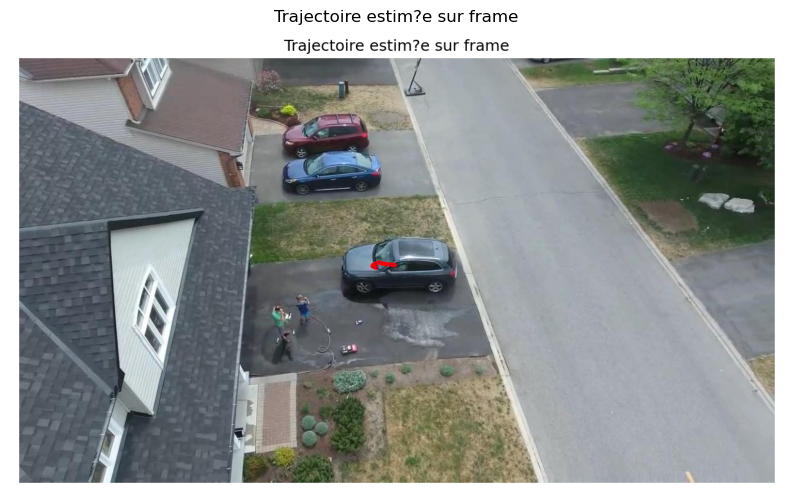

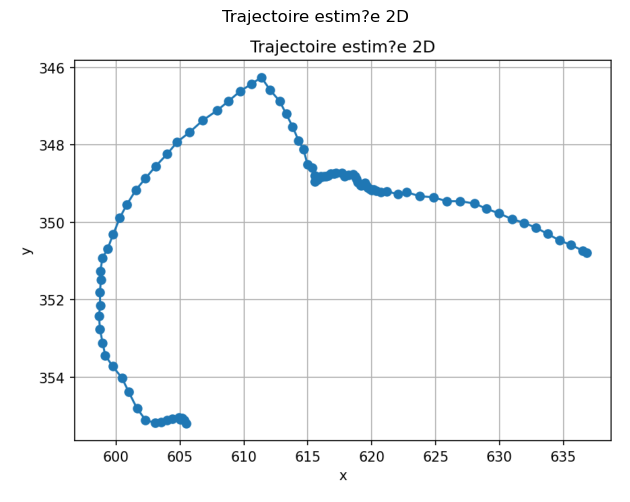

In [6]:
for path, title in [(plots_path / "trajectory_estimated_on_frame.png", "Trajectoire estim?e sur frame"), (plots_path / "trajectory_estimated_2d.png", "Trajectoire estim?e 2D")]:
    if path.exists():
        image = cv2.imread(str(path))
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
        plt.show()
    else:
        print(path.name, "est introuvable")


## 7. Comparaison trajectoire estim?e vs groundtruth


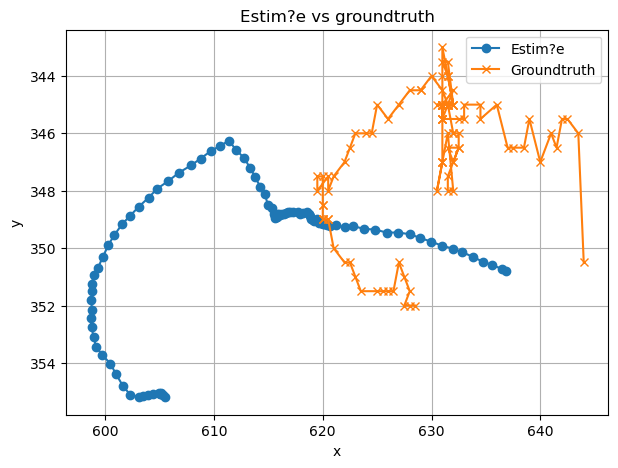

In [7]:
if not comparison_df.empty:
    plt.figure(figsize=(7,5))
    plt.plot(comparison_df["estimated_x"], comparison_df["estimated_y"], marker="o", label="Estim?e")
    plt.plot(comparison_df["groundtruth_x"], comparison_df["groundtruth_y"], marker="x", label="Groundtruth")
    plt.gca().invert_yaxis(); plt.title("Estim?e vs groundtruth"); plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.grid(True)
    plt.show()
else:
    print("Comparaison indisponible.")


## 8. Erreur de suivi


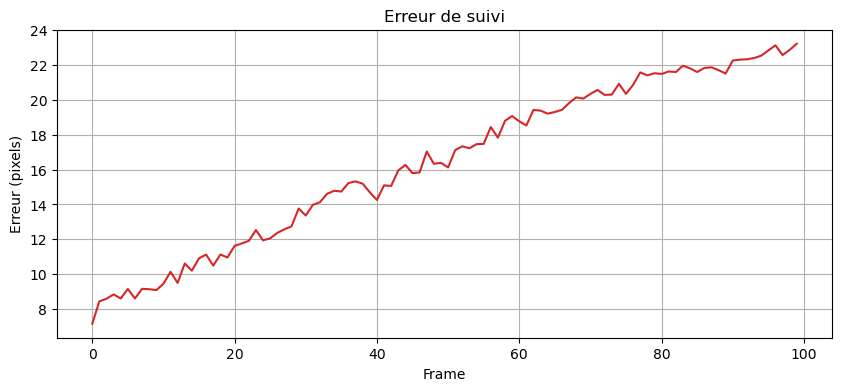

Erreur moyenne : 16.408701201615166
Erreur maximale : 23.21730168568301


In [8]:
if not comparison_df.empty:
    plt.figure(figsize=(10,4))
    plt.plot(comparison_df["frame"], comparison_df["error"], color="tab:red")
    plt.title("Erreur de suivi")
    plt.xlabel("Frame")
    plt.ylabel("Erreur (pixels)")
    plt.grid(True)
    plt.show()
    print("Erreur moyenne :", comparison_df["error"].mean())
    print("Erreur maximale :", comparison_df["error"].max())


## 9. Vitesse


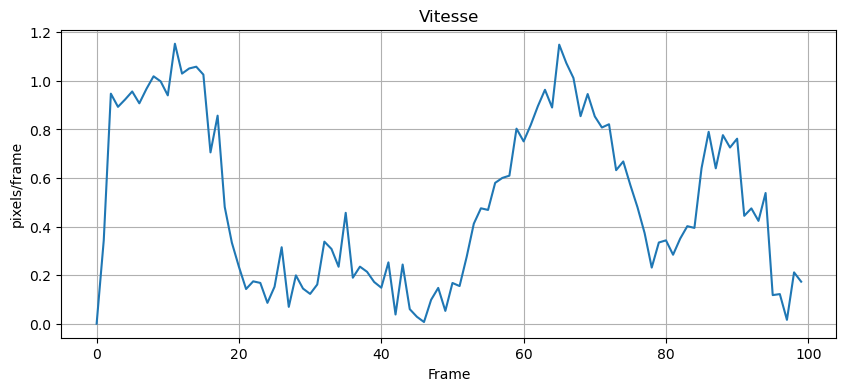

In [9]:
if not analysis_df.empty:
    plt.figure(figsize=(10,4))
    plt.plot(analysis_df["frame"], analysis_df["speed_px_per_frame"], color="tab:blue")
    plt.title("Vitesse")
    plt.xlabel("Frame")
    plt.ylabel("pixels/frame")
    plt.grid(True)
    plt.show()


## 10. Direction


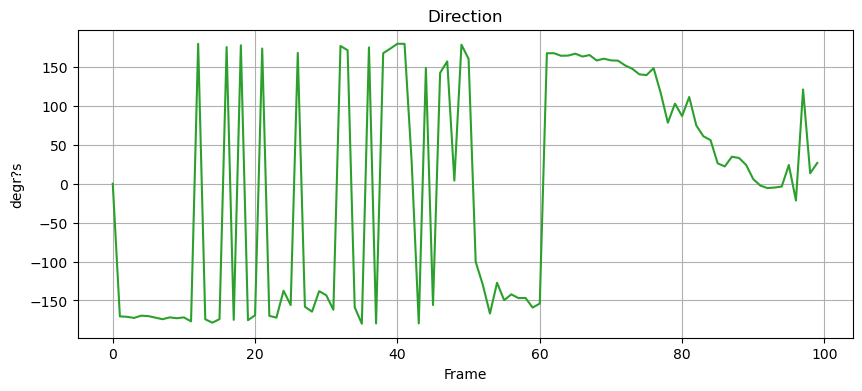

In [10]:
if not analysis_df.empty:
    plt.figure(figsize=(10,4))
    plt.plot(analysis_df["frame"], analysis_df["direction_deg"], color="tab:green")
    plt.title("Direction")
    plt.xlabel("Frame")
    plt.ylabel("degr?s")
    plt.grid(True)
    plt.show()


## 11. Interface Tkinter si disponible


In [11]:
app_path = Path("../app/tkinter_app.py")
if app_path.exists():
    print("Interface disponible : app/tkinter_app.py")
    print("Tracking bas? sur segmentation + Lucas-Kanade")
    print("Groundtruth utilis? uniquement pour comparaison")
else:
    print("Interface Tkinter non disponible.")


Interface disponible : app/tkinter_app.py
Tracking bas? sur segmentation + Lucas-Kanade
Groundtruth utilis? uniquement pour comparaison


## 12. Conclusion

Notre m?thode r?alise une segmentation et une d?tection propres au projet. Le groundtruth est utilis? uniquement pour la comparaison.
